In [451]:
####################################
#ENVIRONMENT SETUP

In [452]:
#LIBRARIES

#system
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import sys

#math and array operations
import numpy as np
import math

#plotting
import matplotlib
# matplotlib.use("Agg") #UNCOMMENT IF PLOTTING WITHIN JUPYTER DOCUMENT
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

#data classes
import xarray as xr
import h5py
import pickle 

#loading bar
from tqdm import tqdm

#dates
from datetime import datetime

In [453]:
#Importing DirectoryManager Class
sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis"))
from CLASSES_Directories import DirectoryManager_Class

In [454]:
DirectoryManager = DirectoryManager_Class()

codeType = os.path.join("DataAnalysis", "MPAS_Model_Data", "VariableComparisons")
dataType = "AreaAverages"

outputDirectory = DirectoryManager.GetOutputDirectory(codeType, dataType)
outputPlottingDirectory = DirectoryManager.GetOutputPlottingDirectory(codeType, dataType)

 DirectoryManager_Class Summary
 Main Directory:           /glade/u/home/aroseman/Projects/Regional-MPAS-Project
 Main Scratch Directory:   /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project
 Scratch Directory:        /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0
 Data Directory:           /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA
 Main Output Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT
 Main Output Plotting Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING
 Main Code Directory:      /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles
 Current Code Directory:   /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/MPAS_Model_Data/VariableComparisons



In [455]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_ModelData import StructuredModelData_Class, DataOperator_Class

In [494]:
#Setup

# Region = "TRACER"; Case = "WET"; spinup_hours = "0"
# Region = "TRACER"; Case = "DIURNAL"; spinup_hours = "-5"
Region = "PRECIP"; Case = "WET"; spinup_hours = "12"
# Region = "PRECIP"; Case = "DIURNAL"; spinup_hours = "12"

# Region = "Hawaii"; Case = "WET"; spinup_hours = "12"; spinup_hours="-16"
# Region = "Hawaii"; Case = "TRADES"; spinup_hours = "24"

In [496]:
#Load Model Directory Class
RunType = (Region,Case,"NSSL",spinup_hours)
ModelData = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

# RunType = (Region,Case,"TEMPO",spinup_hours)
# ModelData_TEMPO = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

Found 241/289 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/Hawaii/WET/MPAS-Model_NSSL/model_run_spinup12hrs/history_cartesian/history.2021-12-05_12.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/Hawaii/WET/MPAS-Model_NSSL/model_run_spinup12hrs/diag_cartesian/diag.2021-12-05_12.00.00.latlon.nc

=== MPAS Structured (lat-lon) Model Data Summary ===
 Region:         Hawaii
 Case:           WET
 Microphysics:   NSSL
 Resolution:     20-1km
 Time Step:      15mins
 Time Range:     2021-12-05 to 2021-12-08
 Coordinates:    ['latitude', 'longitude', 'nVertLevels', 'nVertLevelsP1']
 # History Files:241
 # Diag Files:   241
 # Time Steps:   241
 Data Directory: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/Hawaii/WET/MPAS-Model_NSSL/model_run_spinup12hrs
 Static File:    Hawaii_regional2250_scale

In [497]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_DataSaving import DataSaving_Class

In [498]:
#Importing PlottingModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_PlottingModelData import RadarPlotting_Class

In [499]:
#Importing Radar Classes
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","Observation_Data"))
from CLASSES_RadarDataLoading import RadarData_MRMS_Class, RadarObservationMask_Class

sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_RadarDataPlotting import RadarPlotting_Class

In [500]:
#IMPORT FUNCTIONS
# --- Add your Functions folder to sys.path ---
import sys
path = os.path.join(DirectoryManager.mainCodeDirectory, 'Functions_2.0')
sys.path.append(path)


# --- Import all your function modules ---
import importlib
modules = [
    "AreaAverageFunctions",
    "ComputationFunctions",
    "DataFunctions",
    "DerivativeFunctions",
    "PlottingFunctions",
    "StatisticalFunctions",
]
for mod in modules:
    globals()[mod] = importlib.import_module(mod)        # import module itself
    globals().update(vars(globals()[mod]))              # import all functions into global namespace

In [501]:
####################################
#TESTING WEIGHTED AVERAGES

In [514]:
def GetMean1(variable):
    variableMean = variable.mean(dim=("latitude","longitude"), skipna=True).data
    return variableMean

def GetMean2(variableSubset):
    #(1/A) times integral of phi dA 
    #dA is [(R*cos(Lat)dLon)][RdLat] = R^2 cos(Lat)dLatdLon ==> weight is simply cos(Lat)
    weights = np.cos(np.deg2rad(variableSubset.latitude))
    variableMean = variableSubset.weighted(weights).mean(
        dim=("latitude", "longitude"),
        skipna=True
    )
    return variableMean

In [515]:
# a = ModelData.GetDataTimestep(t=100,varName='w')

# one = GetMean1(a)
# two = GetMean2(a)

# plt.plot(one,color='k')
# plt.plot(two,color='red')

In [462]:
####################################
#TESTING VERTICAL INTERPOLATION

In [655]:
def FindMaxHeightLocation(ModelData):
    terrainHeight = ModelData.initData.zgrid.isel(nVertLevelsP1=0)
    lat_index,lon_index = np.where(terrainHeight==terrainHeight.max())
    lon_location,lat_location = ModelData.longitude[lon_index].item(),ModelData.latitude[lat_index].item()
    return lon_location,lat_location 
    
def SubsetTaiwan(data):
    [lon_location,lat_location] = FindMaxHeightLocation(ModelData)
    distance=0.75
    return data.sel(longitude=slice(lon_location-distance,lon_location+distance),latitude=slice(lat_location-distance,lat_location+distance))

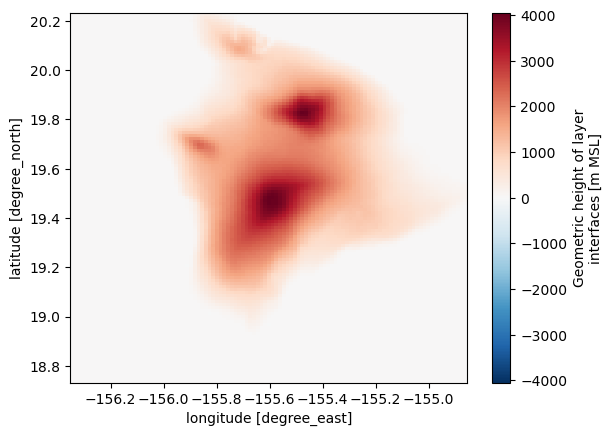

In [656]:
terrainHeight = ModelData.initData.zgrid.isel(nVertLevelsP1=0)
terrainHeight = SubsetTaiwan(terrainHeight)
terrainHeight.plot()

In [ ]:
# def OLD_GetMean(variable,zgrid):
        
#     zgrid_f = zgrid
#     zgrid_c = 0.5 * (
#         zgrid_f.isel(nVertLevelsP1=slice(0, -1)) +
#         zgrid_f.isel(nVertLevelsP1=slice(1, None))
#     )
#     zgrid_c = zgrid_c.rename({"nVertLevelsP1": "nVertLevels"})
#     terrainHeight = zgrid_f.isel(nVertLevelsP1=0)
    
#     zgridAGL_f = zgrid_f - terrainHeight
#     zgridAGL_c = zgrid_c - terrainHeight
#     dz = zgridAGL_f.diff("nVertLevelsP1")   # shape: (z, lat, lon)
    
#     zBins = ModelData.zf
#     nBins = len(zBins) - 1
    
#     zFlat = zgridAGL_c.values.ravel()/1e3
#     binIndex = np.digitize(zFlat, zBins) -1 
#     dzFlat = dz.values.ravel()
    
#     variableFlat = variable.values.ravel()
#     variableSum = np.zeros(nBins)
#     variableCount = np.zeros(nBins)
    
#     np.add.at(variableSum,   binIndex, variableFlat * dzFlat)
#     np.add.at(variableCount, binIndex, dzFlat)
#     variableMean = variableSum / variableCount       
#     return variableMean

In [761]:
varName = 'uReconstructZonal'
varName = 'w'
variableSubset = ModelData.GetDataTimestep(t=60,varName=varName)
variableSubset = SubsetTaiwan(variableSubset)

zGrid=ModelData.initData.zgrid
zGrid = SubsetTaiwan(zGrid)

Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/Hawaii/WET/MPAS-Model_NSSL/model_run_spinup12hrs/history_cartesian/history.2021-12-06_03.00.00.latlon.nc


In [762]:
# def GetMean2()
zGrid -= zGrid.isel(nVertLevelsP1=0)
zGrid_f = zGrid
zGrid_c = 0.5 * (
    zGrid_f.isel(nVertLevelsP1=slice(0, -1)) +
    zGrid_f.isel(nVertLevelsP1=slice(1, None))
); zGrid_c = zGrid_c.rename({"nVertLevelsP1": "nVertLevels"})


In [763]:
zGrid = zGrid_f if varName in ['w'] else zGrid_c
zTarget = ModelData.zf*1e3 if varName in ['w'] else ModelData.zc*1e3
zDim = "nVertLevelsP1" if varName in ['w'] else "nVertLevels"

In [764]:
def interpColumn(varCol, zCol, zTarget):
    # ---- convert to NumPy explicitly
    varCol = np.asarray(varCol)
    zCol   = np.asarray(zCol)

    valid = np.isfinite(varCol) & np.isfinite(zCol)
    if valid.sum() < 2:
        return np.full(len(zTarget), np.nan)

    # ---- enforce monotonic z
    order = np.argsort(zCol[valid])

    return np.interp(
        zTarget,
        zCol[valid][order],
        varCol[valid][order],
        left=np.nan,
        right=np.nan
    )


[lon_location,lat_location] = FindMaxHeightLocation(ModelData)
varCol = variableSubset.sel(latitude=lat_location,longitude=lon_location)
zCol = zGrid.sel(latitude=lat_location,longitude=lon_location)
zTarget = ModelData.zf*1e3

varInterp = interpColumn(varCol, zCol, zTarget)

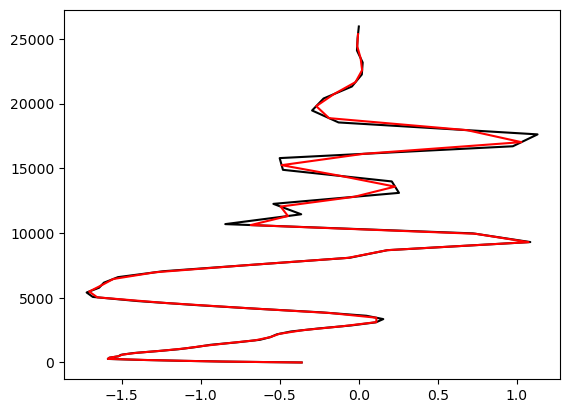

In [765]:
plt.plot(varCol,zCol,color='k')
plt.plot(varInterp,zTarget,color='red')

In [766]:
def InterpolateVertical(variableSubset,zgrid,zTarget,zDim):
    """
    Column-wise vertical interpolation to fixed height levels.
    """

    def interpColumn(varCol, zCol, zTarget):
        valid = np.isfinite(varCol) & np.isfinite(zCol)
        if valid.sum() < 2:
            return np.full(len(zTarget), np.nan)

        return np.interp(
            zTarget,
            zCol[valid],
            varCol[valid],
            left=np.nan,
            right=np.nan
        )

    varInterp = xr.apply_ufunc(
        interpColumn,
        variableSubset,
        zgrid,
        input_core_dims=[[zDim], [zDim]],
        output_core_dims=[["z"]],
        vectorize=True,
        kwargs={"zTarget": zTarget},
        output_dtypes=[variableSubset.dtype],
    )

    varInterp = varInterp.assign_coords(
        z=("z", zTarget),
        latitude=variableSubset.latitude,
        longitude=variableSubset.longitude,
    )

    varInterp.name = variableSubset.name

    return varInterp


In [767]:
variableSubset_interpZ = InterpolateVertical(variableSubset,zGrid,zTarget,zDim)


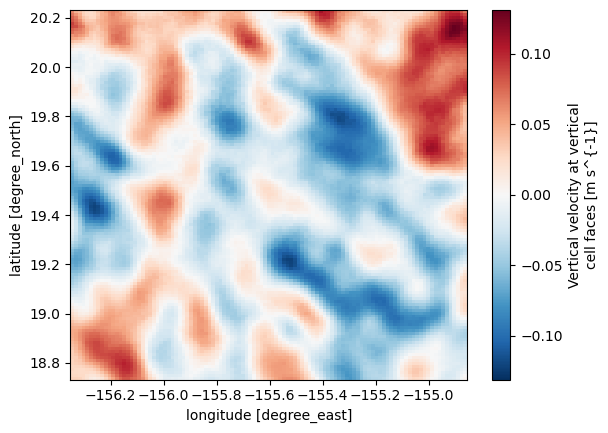

In [789]:
variableSubset.isel(nVertLevelsP1=53).plot()

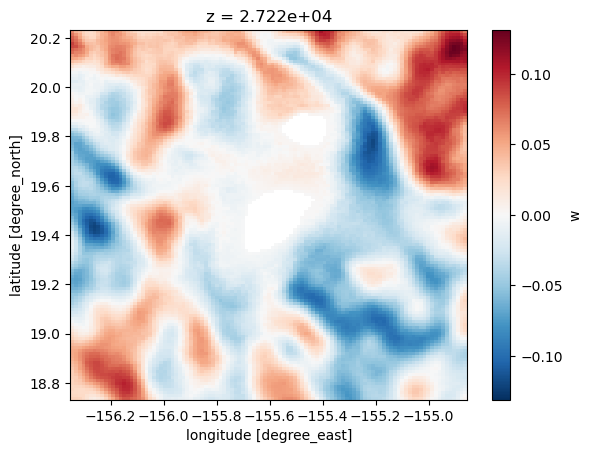

In [790]:
variableSubset_interpZ.isel(z=53).plot()

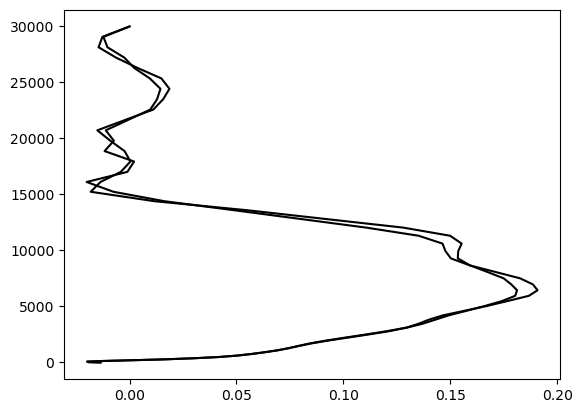

In [788]:
plt.plot(GetMean2(variableSubset),ModelData.zf*1e3,color='k')
plt.plot(GetMean2(variableSubset_interpZ),variableSubset_interpZ.z,color='k')


In [449]:
mean1 =  GetMean1(variable)
mean2 =  GetMean2(variable,zgrid)

Text(0, 0.5, 'z (km)')

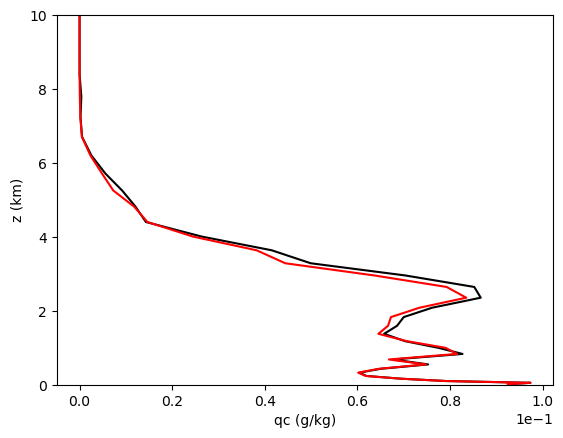

In [450]:
multiplier=1e3
plt.plot(multiplier*mean1,ModelData.zc,color='black')
plt.ylim(0,10)
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.xlabel('qc (g/kg)')
plt.ylabel('z (km)')

##################

multiplier=1e3
plt.plot(multiplier*mean2,ModelData.zc,color='red')
plt.ylim(0,10)
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.xlabel('qc (g/kg)')
plt.ylabel('z (km)')